# **MCZA018 – Processamento Digital de Imagens**

### **Laboratório 5 – Cores em Imagens e Vídeo**


### Este arquivo fornece códigos de funções úteis e necessárias para executar os roteiros das **(3) Atividades Práticas Experimentais** do Lab.5 - Cores em Imagens e Video, fornecido no arquivo pdi26__Lab5_img_colors_.pdf.

### 2. Pré-requisitos

* Python 3.x, NumPy, OpenCV e Matplotlib.
* Imagens coloridas `.png` ou `.jpg` de alta qualidade.

---

### 3. Atividades Práticas Experimentais

### 3.1. Correção de Ponto Branco (White Point Correction - 4.1.11)

A correção de ponto branco ajusta a iluminação para que objetos brancos pareçam brancos sob diferentes fontes de luz. Usaremos a transformação de von Kries:
$C_{new} = C_{old} \cdot (W_{target} / W_{source})$.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def white_point_correction(img, sourcewp, targetwp):
    # img escala [0, 1]
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)


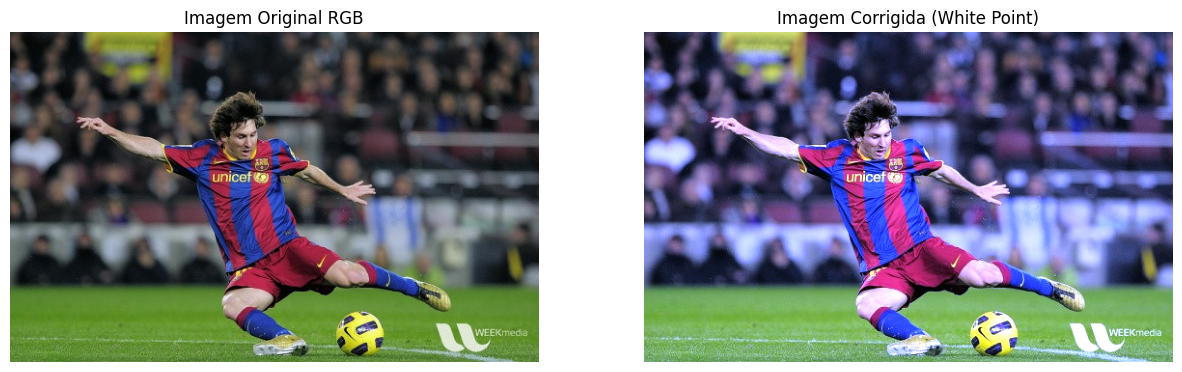

In [ ]:
# Exemplo: Corrigindo de uma luz quente (amarelada) para D65 (luz do dia)
img = cv2.imread('../data/messi5.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) /255.0

# Simplificação: canais R, G, B
source_wp = np.array([0.8, 0.8, 0.5])
target_wp = np.array([1.0, 1.0, 1.0])
corrected_img = white_point_correction(img_rgb, source_wp, target_wp)

# Mostra a imagem corrigida
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.imshow(img_rgb) # Display the original image (normalized)
plt.title('Imagem Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.imshow(corrected_img)
plt.title('Imagem Corrigida (White Point)')
plt.axis('off')

plt.show()

### 3.2. Transformação XYZ para RGB e Correção Gama (4.1.12 e 4.1.13)

O espaço $XYZ$ é independente de dispositivo, mas para exibição em monitores, precisamos converter para $RGB$ e aplicar a lei de potência (Gama).

In [4]:
def xyz_to_rgb_gamma(xyz_img):
    # Matriz de conversão linear XYZ para RGB (exemplo para D65)
    matrix = np.array([[3.2406, -1.5372, -0.4986],
                       [-0.9689, 1.8758, 0.0415],
                       [0.0557, -0.2040, 1.0570]])

    rgb_linear = xyz_img @ matrix.T
    rgb_linear = np.clip(rgb_linear, 0, 1)

    # Correção Gama (4.1.13): sRGB standard
    # Aproximação: C = 1.055 * L^(1/2.4) - 0.055
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return gamma_corrected

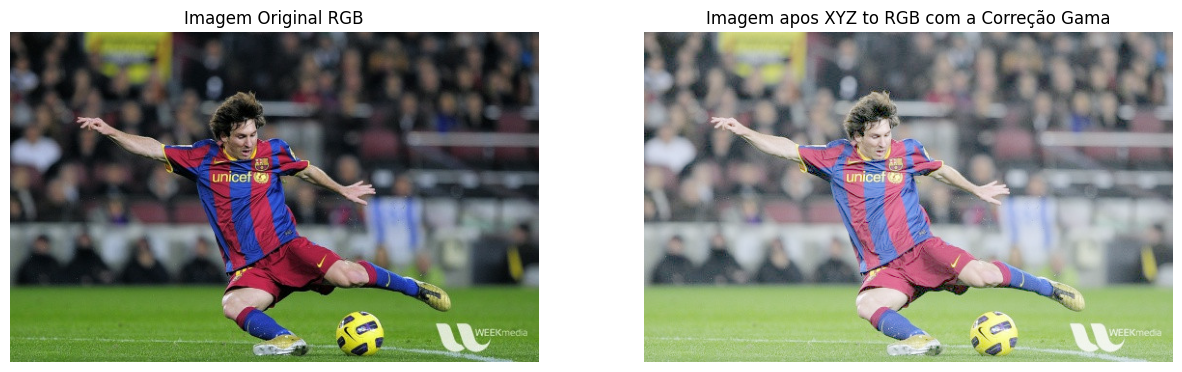

In [5]:
# APLICANDO A CORREÇÃO GAMA EM UMA IMAGEM

# É necessário ter a imagem RGB no formato correto para a conversão.
# Como `img_rgb` foi obtida de `cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) / 255.0`,
# ela já está no formato RGB e normalizada.
# A função cvtColor do OpenCV, que converte de RGB para XYZ, 
# espera valores float32 e valores entre 0 e 1 para tipos CV_32F.

img_rgb_float32 = img_rgb.astype(np.float32)
img_xyz = cv2.cvtColor(img_rgb_float32, cv2.COLOR_RGB2XYZ)

# Aplicando a funcao xyz_to_rgb_gamma :
gamma_corrected_xyz_to_rgb = xyz_to_rgb_gamma(img_xyz)

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1) 
plt.imshow(img_rgb)
plt.title('Imagem Original RGB')
plt.axis('off')

plt.subplot(1, 2, 2) 
plt.imshow(gamma_corrected_xyz_to_rgb)
plt.title('Imagem apos XYZ to RGB com a Correção Gama')
plt.axis('off')

plt.show()

### 3.3. O Modelo CIELAB ($L^*a^*b^*$) (4.1.14)

Este modelo é projetado para ser perceptualmente uniforme. $L^*$ representa a luminosidade, enquanto $a^*$ e $b^*$ são as dimensões de oponência de cor.

* **Tarefa:** Utilize `cv2.cvtColor(img, cv2.COLOR_BGR2Lab)` e visualize os canais separadamente para identificar como a informação de brilho é isolada da cor.



In [6]:
def plot_color_cielab(img):
    lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)

    l_channel, a_channel, b_channel = cv2.split(lab_img)

    img_rgb_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb_display)
    plt.title('Imagem Original (RGB)')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(l_channel, cmap='gray')
    plt.title('Canal L* (Luminosidade)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(a_channel, cmap='gray') 
    plt.title('Canal a* (Verde-Vermelho)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(b_channel, cmap='gray')
    plt.title('Canal b* (Azul-Amarelo)')
    plt.axis('off')

    plt.show()

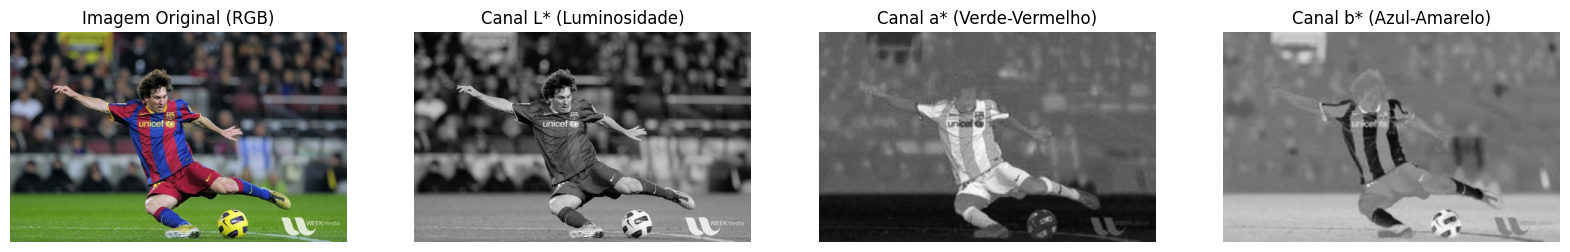

In [7]:
plot_color_cielab(img)

### 3.4. Cores Dependentes de Câmera: HSV e sRGB (4.2.3)

O $HSV$ (Hue, Saturation, Value) é uma transformação não linear do $RGB$ que facilita a segmentação de objetos por cor, independente da intensidade luminosa.

Diferente do RGB, onde uma cor "azul" pode ter valores muito diferentes dependendo do brilho, no HSV o azul está concentrado em uma faixa específica do canal **H** (Hue).

In [8]:
# Segmentação simples usando HSV 
# Observe a geração da máscara azul com a função inRange()

hsv = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_RGB2HSV)
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([130, 255, 255])
mask = cv2.inRange(hsv, lower_blue, upper_blue)

**Exemplo prático de segmentação pela cor no Espaço HSV**

Execute o exemplo abaixo para a cor VERDE.

In [9]:
def segmentar_por_cor(img_bgr):
    # 1. Converter para HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # 2. Definir o intervalo da cor desejada (Exemplo: Verde)
    # No OpenCV: H vai de 0 a 179, S e V de 0 a 255
    verde_baixo = np.array([35, 50, 50])
    verde_alto = np.array([85, 255, 255])

    # 3. Criar uma máscara binária
    mask = cv2.inRange(hsv, verde_baixo, verde_alto)

    # 4. Aplicar a máscara na imagem original
    resultado = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

    return mask, resultado

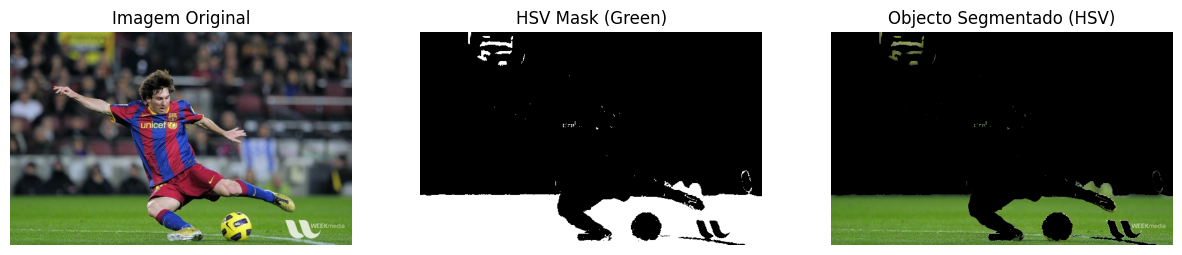

In [10]:
# Apresentação das etapas
# Obs. assumindo que a imagem 'img_bgr' já foi previamente gerada:
if 'img' in locals() and img is not None:
    mask_hsv, segmented_object_hsv = segmentar_por_cor(img)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask_hsv, cmap='gray')
    plt.title('HSV Mask (Green)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(segmented_object_hsv, cv2.COLOR_BGR2RGB))
    plt.title('Objecto Segmentado (HSV)')
    plt.axis('off')

    plt.show()
else:
    print("Error: 'img_bgr' is not defined. Please ensure the image is loaded first.")

### 3.5. Modelo $YCbCr$ (4.3.4)

Essencial para compressão de vídeo (MPEG, JPEG). Ele separa a Luminância ($Y$) da Crominância ($Cb$ e $Cr$).

A transformação padrão (BT.601) segue:


$$Y = 0.299R + 0.587G + 0.114B$$

$$Cb = 0.564(B - Y)$$

$$Cr = 0.713(R - Y)$$

In [11]:
def rgb_to_ycbcr(rgb_img):
    # Coeficientes do livro (Seção 4.3.4)
    transform_mat = np.array([[0.299, 0.587, 0.114],
                              [-0.1687, -0.3313, 0.5],
                              [0.5, -0.4187, -0.0813]])
    # Ajuste de offset para Cb e Cr (normalmente 128 em 8 bits)
    ycbcr = rgb_img @ transform_mat.T
    ycbcr[:,:,1:] += 0.5
    return np.clip(ycbcr, 0, 1)

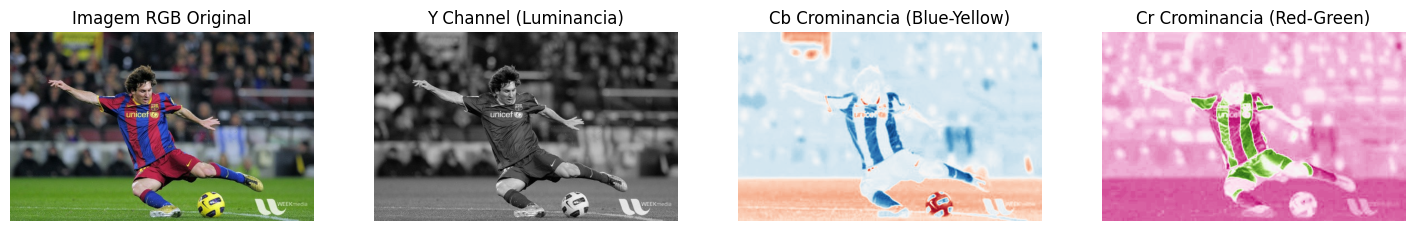

In [12]:
# Apresentação dos canais Y, Cb, Cr:
# Obs. assumindo que a imagem 'img_rgb' já foi previamente gerada:
if 'img_rgb' in locals() and img_rgb is not None:
    # Aplicar a função rgb_to_ycbcr
    ycbcr_img = rgb_to_ycbcr(img_rgb)

    # Separar os canais Y, Cb e Cr
    Y_channel = ycbcr_img[:, :, 0]
    Cb_channel = ycbcr_img[:, :, 1]
    Cr_channel = ycbcr_img[:, :, 2]

    # Plotar a imagem original e os canais separados
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Imagem RGB Original')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(Y_channel, cmap='gray')
    plt.title('Y Channel (Luminancia)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(Cb_channel, cmap='RdBu') # Red-Blue para Cb
    plt.title('Cb Crominancia (Blue-Yellow)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(Cr_channel, cmap='PiYG') # Pink-Yellow-Green para Cr
    plt.title('Cr Crominancia (Red-Green)')
    plt.axis('off')

    plt.show()
else:
    print("Erro: 'img_rgb' não está definida. Por favor, carregue a imagem RGB primeiro.")

### Visualização de Decomposição de Cores dos canais **$L^*a^*b^*$** e **$YCbCr$**

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_color_decomposition(img_path):
    # Carregar imagem original (BGR) e converter para RGB para o Matplotlib
    bgr = cv2.imread(img_path)
    if bgr is None:
        print("Erro ao carregar a imagem.")
        return
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # 1. Transformação para LAB (Seção 4.1.14)
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2Lab)
    l_chan, a_chan, b_chan = cv2.split(lab)

    # 2. Transformação para YCbCr (Seção 4.3.4)
    ycbcr = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb) # OpenCV usa YCrCb por padrão
    y_chan, cr_chan, cb_chan = cv2.split(ycbcr)

    # Configuração do Plot
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    # Linha 1: Original e Espaço LAB
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title("Original (RGB)")
    axes[0, 1].imshow(l_chan, cmap='gray')
    axes[0, 1].set_title("LAB: Canal L* (Luminosidade)")
    axes[0, 2].imshow(a_chan, cmap='RdYlGn_r') # Red-Green para o eixo 'a'
    axes[0, 2].set_title("LAB: Canal a* (Verde-Vermelho)")

    # Linha 2: Continuação LAB e Espaço YCbCr
    axes[1, 0].imshow(b_chan, cmap='YlGnBu_r') # Yellow-Blue para o eixo 'b'
    axes[1, 0].set_title("LAB: Canal b* (Azul-Amarelo)")
    axes[1, 1].imshow(y_chan, cmap='gray')
    axes[1, 1].set_title("YCbCr: Canal Y (Luma)")
    axes[1, 2].imshow(cb_chan, cmap='jet')
    axes[1, 2].set_title("YCbCr: Canal Cb (Crominância Azul)")

    # Linha 3: Canal Cr e histogramas para análise
    axes[2, 0].imshow(cr_chan, cmap='jet')
    axes[2, 0].set_title("YCbCr: Canal Cr (Crominância Vermelha)")

    # Histograma de Luminância para comparar L* vs Y
    axes[2, 1].hist(l_chan.ravel(), bins=256, color='black', alpha=0.5, label='L*')
    axes[2, 1].hist(y_chan.ravel(), bins=256, color='blue', alpha=0.3, label='Y')
    axes[2, 1].set_title("Histograma: L* (LAB) vs Y (YCbCr)")
    axes[2, 1].legend()

    # Desativar eixos para as imagens
    for i in range(3):
        for j in range(3):
            if not (i == 2 and j == 1):
                axes[i, j].axis('off')

    plt.show()


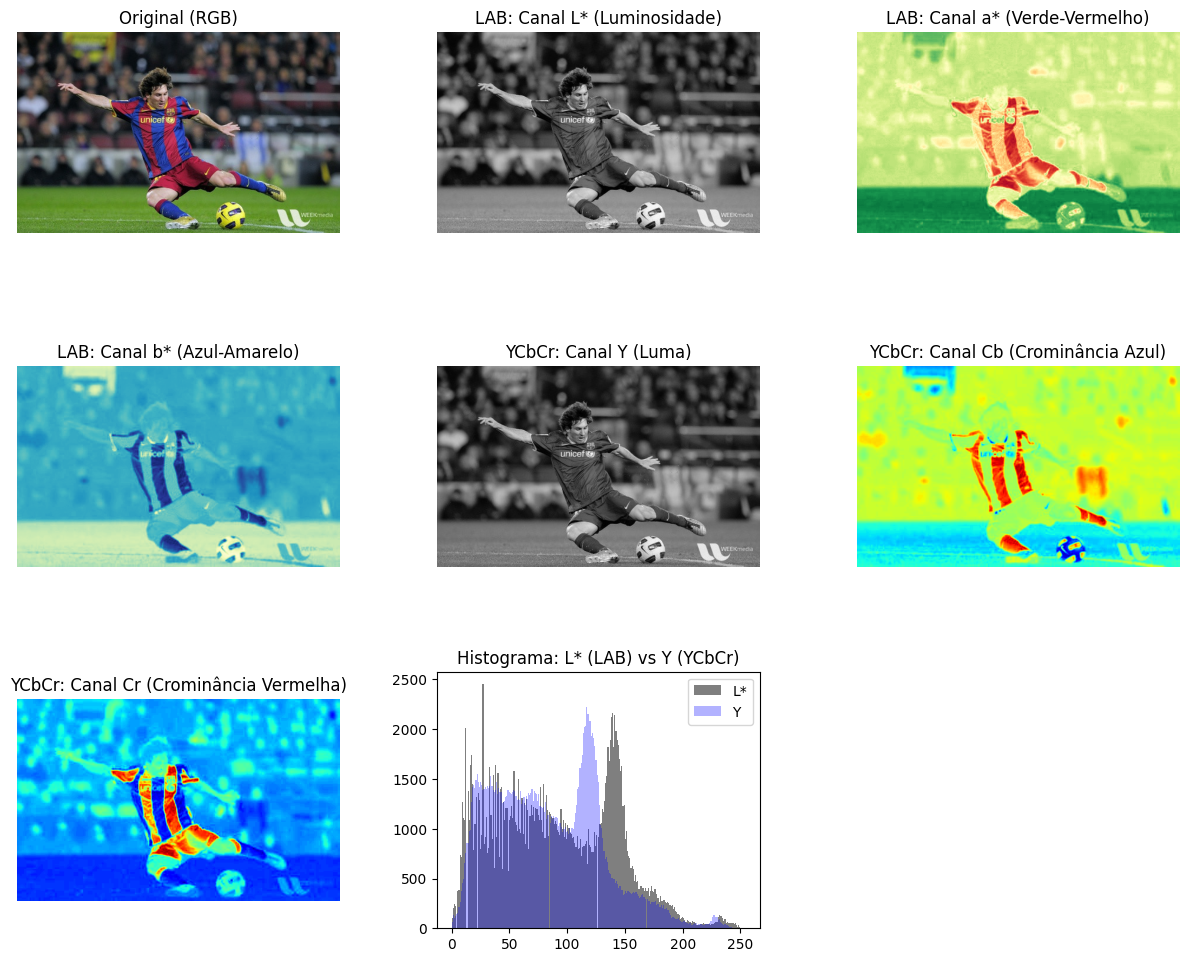

In [24]:
plot_color_decomposition('../data/img/messi5.jpg')

## 3.6 

Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as operações de correção de ponto branco, e a correção gama, mostrando na tela o resultado em tempo real, permitindo ao operador escolher a visualização da imagem original, correção ponto branco, ou correção gama, ou ambas. 

Grave um video demonstrativo com os integrantes do grupo.

In [19]:
def white_point_correction(img, sourcewp, targetwp):
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)

def apply_gamma(rgb_linear):
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return np.clip(gamma_corrected, 0, 1)

cap = cv2.VideoCapture(0)
mode = 'original'

print("Teclas de controle:")
print("'1' - Original | '2' - Ponto Branco | '3' - Gama | '4' - Ambos | 'q' - Sair")

while True:
    ret, frame = cap.read()
    if not ret: break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) / 255.0
    
    display_frame = frame_rgb.copy()

    if mode == 'wp' or mode == 'ambos':
        source_wp = np.array([0.9, 0.9, 0.7]) 
        target_wp = np.array([1.0, 1.0, 1.0])
        display_frame = white_point_correction(display_frame, source_wp, target_wp)
    
    if mode == 'gama' or mode == 'ambos':
        display_frame = apply_gamma(display_frame)

    final_frame = cv2.cvtColor((display_frame * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    
    cv2.putText(final_frame, f"Modo: {mode}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('Laboratorio 5 - Ex 3.6', final_frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('1'): mode = 'original'
    elif key == ord('2'): mode = 'wp'
    elif key == ord('3'): mode = 'gama'
    elif key == ord('4'): mode = 'ambos'
    elif key == ord('q'): break

cap.release()
cv2.destroyAllWindows()

2026-03-20 20:24:38.503 Python[2452:3529435] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


Teclas de controle:
'1' - Original | '2' - Ponto Branco | '3' - Gama | '4' - Ambos | 'q' - Sair


## 3.7

Elabore um programa para realizar continuamente sobre a imagem da WEBCAM a detecção de uma cor pelo método HSV, mostrando lado-a-lado na tela a imagem original, e a imagem somente com as partes detectadas. 

Grave um video demonstrativo com os integrantes do grupo.

In [22]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

size = (width * 2, height) 

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('../data/vid/demonstracao_hsv.avi', fourcc, 20.0, size)

lower_color = np.array([100, 50, 50])
upper_color = np.array([130, 255, 255])

print("A gravar... Pressione 'q' para parar e salvar.")

while True:
    ret, frame = cap.read()
    if not ret: break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, lower_color, upper_color)
    segmented = cv2.bitwise_and(frame, frame, mask=mask)

    combined = np.hstack((frame, segmented))

    out.write(combined)

    cv2.imshow('Gravando: Original vs Segmentada', combined)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()
print("Vídeo salvo como 'demonstracao_hsv.avi'")

A gravar... Pressione 'q' para parar e salvar.
Vídeo salvo como 'demonstracao_hsv.avi'


---

## 4. Exercícios Propostos

(Elabore um código separamente para cas exercício)

1. **Comparação de Luminosidade:** Compare o canal $L^*$ do CIELAB com o canal $Y$ do $YCbCr$. Qual deles parece preservar melhor os detalhes de sombreamento da imagem original?
2. **Efeito Gama:** Aplique uma correção gama inversa ($\gamma = 2.2$) em uma imagem clara e observe a perda de detalhe nas áreas escuras.
3. **Filtro de Cor:** Use o espaço $YCbCr$ para remover a cor de uma imagem (torná-la escala de cinza) zerando os canais $Cb$ e $Cr$ e reconstruindo-a em $RGB$.

4. **O Desafio do Semáforo ou Objeto Colorido**
Escolha uma imagem que contenha objetos com as cores primárias bem definidas (ex: um semáforo, peças de LEGO ou frutas).

      (a). Tente segmentar um objeto específico usando o espaço **RGB** (definindo limites para R, G e B separadamente).

      (b). Realize a mesma segmentação usando o espaço **HSV**.

      (c). Compare os resultados: qual método foi mais fácil de configurar? Qual lidou melhor com as áreas de sombra do objeto?

Elabore aqui os programas para resolver os exercícios propostos.

#### 4.1 Comparação de Luminosidade

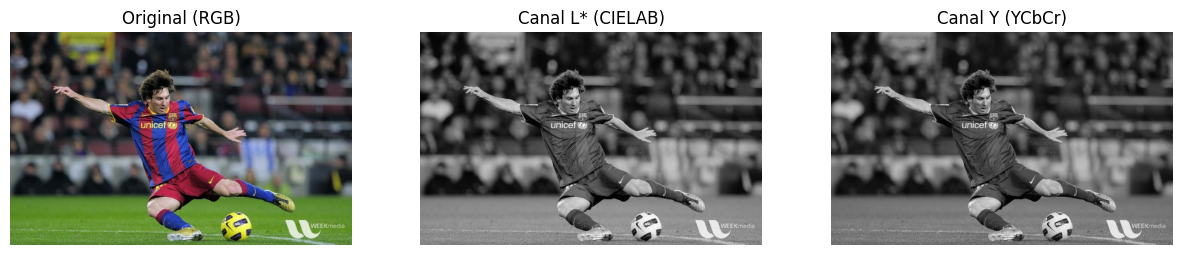

Análise: O canal L* (CIELAB) é projetado para ser perceptualmente uniforme, o que significa que ele reflete a variação de luminosidade da mesma forma que o olho humano percebe. Geralmente, ele preserva melhor os detalhes de sombreamento e contraste em áreas escuras e claras do que o canal Y, que é uma transformação linear matemática direta do RGB.


In [15]:
lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
l_channel, _, _ = cv2.split(lab_img)

# Converter para YCrCb (OpenCV usa YCrCb) e extrair Y
ycc_img = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
y_channel, _, _ = cv2.split(ycc_img)

# Converter original para RGB para exibição
img_rgb_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb_display)
plt.title('Original (RGB)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(l_channel, cmap='gray')
plt.title('Canal L* (CIELAB)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(y_channel, cmap='gray')
plt.title('Canal Y (YCbCr)')
plt.axis('off')

plt.show()

print("Análise: O canal L* (CIELAB) é projetado para ser perceptualmente uniforme, o que significa que ele reflete a variação de luminosidade da mesma forma que o olho humano percebe. Geralmente, ele preserva melhor os detalhes de sombreamento e contraste em áreas escuras e claras do que o canal Y, que é uma transformação linear matemática direta do RGB.")

#### 4.2 Efeito Gama

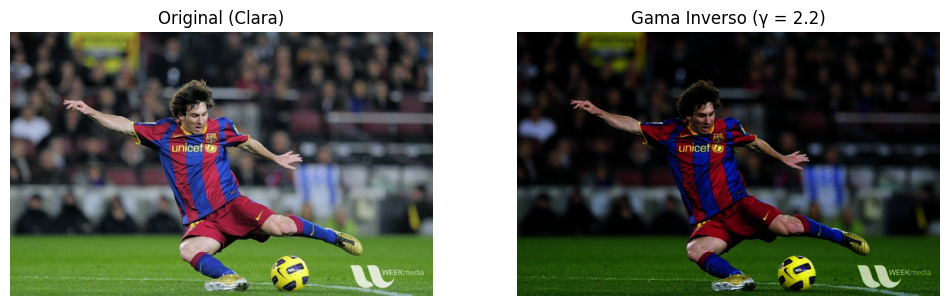

Observação: Ao aplicar o gama inverso (> 1), a imagem escurece consideravelmente. Os tons médios e escuros são empurrados para perto de zero, causando perda de detalhes em áreas que já tinham pouca iluminação (esmagamento das sombras).


In [16]:
gamma_value = 2.2

img_inverse_gamma = np.power(img_rgb, gamma_value)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original (Clara)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_inverse_gamma)
plt.title(f'Gama Inverso (\u03B3 = {gamma_value})')
plt.axis('off')

plt.show()

print("Observação: Ao aplicar o gama inverso (> 1), a imagem escurece consideravelmente. Os tons médios e escuros são empurrados para perto de zero, causando perda de detalhes em áreas que já tinham pouca iluminação (esmagamento das sombras).")

#### 4.3 Filtro de Cor

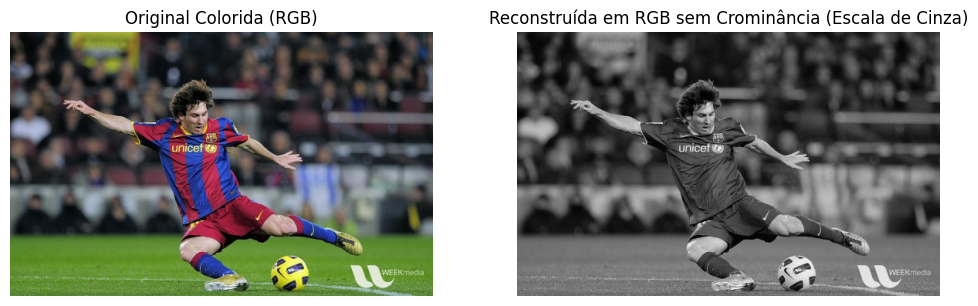

In [17]:
ycc_img = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

y_chan, cr_chan, cb_chan = cv2.split(ycc_img)

cr_zero = np.full_like(cr_chan, 128)
cb_zero = np.full_like(cb_chan, 128)

ycc_gray = cv2.merge([y_chan, cr_zero, cb_zero])

bgr_reconstructed = cv2.cvtColor(ycc_gray, cv2.COLOR_YCrCb2BGR)
rgb_reconstructed = cv2.cvtColor(bgr_reconstructed, cv2.COLOR_BGR2RGB)

img_rgb_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb_display)
plt.title('Original Colorida (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_reconstructed)
plt.title('Reconstruída em RGB sem Crominância (Escala de Cinza)')
plt.axis('off')

plt.show()


#### 4.4 O Desafio do Semáforo ou Objeto Colorido

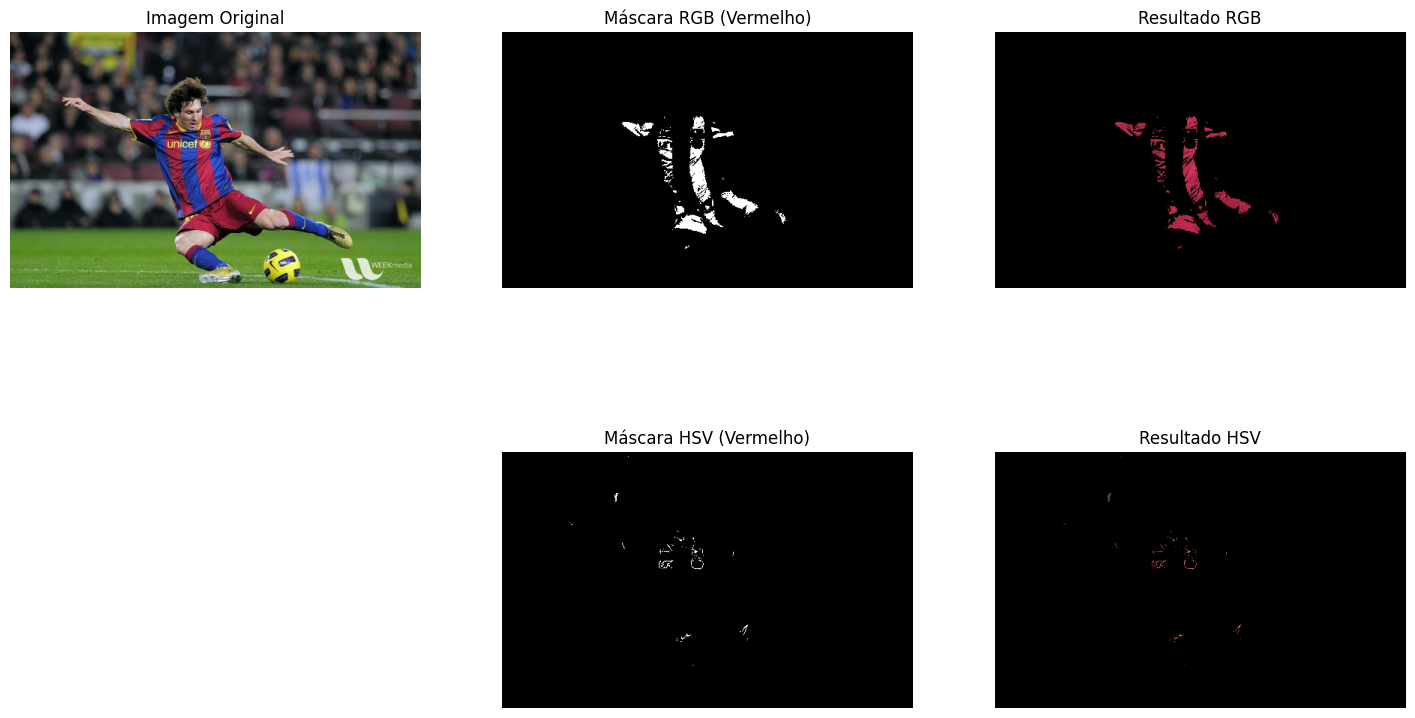

In [18]:
img_rgb_8bit = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lower_rgb = np.array([150, 0, 0]) 
upper_rgb = np.array([255, 100, 100])
mask_rgb = cv2.inRange(img_rgb_8bit, lower_rgb, upper_rgb)
res_rgb = cv2.bitwise_and(img_rgb_8bit, img_rgb_8bit, mask=mask_rgb)

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower_hsv = np.array([0, 100, 100])
upper_hsv = np.array([10, 255, 255])
mask_hsv = cv2.inRange(img_hsv, lower_hsv, upper_hsv)
res_hsv = cv2.bitwise_and(img_rgb_8bit, img_rgb_8bit, mask=mask_hsv)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb_8bit)
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(mask_rgb, cmap='gray')
plt.title('Máscara RGB (Vermelho)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(res_rgb)
plt.title('Resultado RGB')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(mask_hsv, cmap='gray')
plt.title('Máscara HSV (Vermelho)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(res_hsv)
plt.title('Resultado HSV')
plt.axis('off')

plt.show()

4 (c). Comparação dos Resultados

Ao analisar os resultados acima, podemos concluir os seguintes pontos baseados na teoria de processamento de imagens:

Facilidade de Configuração: O método HSV é geralmente mais fácil de configurar. Isso ocorre porque a cor (matiz) está isolada em um único canal (H). No RGB, para definir uma cor "pura", você precisa ajustar os limites de três canais simultaneamente, o que é menos intuitivo.

Lidando com Sombras: O espaço HSV lida muito melhor com áreas de sombra. Em uma sombra, a intensidade luminosa diminui drasticamente (o que alteraria os valores de R, G e B de forma desigual), mas a "cor" (Hue) permanece relativamente constante.

Robustez: No RGB, se uma parte do objeto estiver sob luz forte ou sombra, ela pode facilmente "escapar" do intervalo definido. No HSV, como a iluminação está separada no canal V (Value), a segmentação pela matiz (H) torna-se mais robusta a variações de brilho.